# Figure 2 (`make_figure_2.ipynb`)

**Figure 1** is omitted here by design.

**Figure 2** (below): one row of LS entropy-deficit curves \(\ln|D| - S\) vs SNR (same style as `toy_gaussian_field_ls_els_bbels_entropy.ipynb` / 5×5 LS), for five datasets. Subpanels are labeled **(b)–(f)**. Outputs are written under `results/` as PNG and SVG.

Heavy computation is in its own cells so you can re-run plotting without recomputing.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch


def _project_root() -> Path:
    """Find repo root (contains scripts/sample_hierarchy_synthetic_images.py and src/)."""
    here = Path.cwd().resolve()
    seeds = [here]
    if here.name == "notebooks":
        seeds.append(here.parent)
    sub = here / "convolutional_diffusion"
    if sub.is_dir():
        seeds.append(sub.resolve())
    for start in seeds:
        for p in [start, *start.parents]:
            if (
                (p / "scripts" / "sample_hierarchy_synthetic_images.py").is_file()
                and (p / "src").is_dir()
            ):
                return p
    raise FileNotFoundError(
        "Could not find convolutional_diffusion repo root from cwd=%r. "
        "cd into the repo or notebooks/ under it, or set os.chdir('/path/to/convolutional_diffusion')."
        % (here,)
    )


ROOT = _project_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import importlib.util
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from src.utils.data import get_dataset
from src.utils.idealscore import LocalScoreModule
from src.utils.noise_schedules import cosine_noise_schedule

_hier_path = ROOT / "scripts" / "sample_hierarchy_synthetic_images.py"
_spec = importlib.util.spec_from_file_location("hier_synth", _hier_path)
_hier = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_hier)
sample_hierarchical_mixture_gaussian_images = _hier.sample_hierarchical_mixture_gaussian_images

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT, "device:", device)

ROOT: /home/users/hshunt/convolutional_diffusion device: cuda


## Figure 2 — compute entropy deficits (slow)

5×5 `LocalScoreModule`, cosine schedule, \(\mathrm{SNR} = \alpha_t/\beta_t\). Training caps \(|D|\) are powers of two (capped by dataset size).

In [3]:
# Shared settings (match toy notebook LS 5x5 cell style)
kernel_size_ls = 5
score_batch_size_ls = 64
t_grid_ls = np.linspace(0.02, 0.9, 10).tolist()
n_train_powers = [8, 10, 12, 14]
synthetic_train_size = 50_000
empty_cache_each_call = device.type == "cuda"

with torch.no_grad():
    t_tensor = torch.tensor(t_grid_ls, device=device, dtype=torch.float32)
    beta_t_grid = cosine_noise_schedule(t_tensor)
    snr_grid_ls = ((1.0 - beta_t_grid) / (beta_t_grid + 1e-12)).cpu().numpy()


def posterior_entropy_nats_from_ls(ls_module, t, xt, dev):
    """Mean posterior entropy (nats) from LS; use module kernel size (do not hard-code k)."""
    out = ls_module.forward_with_posterior_stats(t, xt, device=dev)
    return float(out[2].mean().item())


def build_toeplitz_like_dataset(n_samples, image_size=32, alpha=1.7, sigma_sq=1.0, seed=0):
    """Distance-kernel Gaussian field on a 2D grid (same construction as toy Toeplitz sanity cell)."""
    H = W = image_size
    Npix = H * W
    ys = torch.arange(H, dtype=torch.float64)
    xs = torch.arange(W, dtype=torch.float64)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([yy.reshape(-1), xx.reshape(-1)], dim=1)
    r = torch.cdist(coords, coords, p=2)
    r_safe = torch.clamp(r, min=1.0)
    if abs(alpha - 2.0) < 1e-6:
        C = sigma_sq * torch.log(r_safe)
    else:
        C = sigma_sq / (r_safe ** (2.0 - alpha))
    idx = torch.arange(Npix)
    C[idx, idx] = sigma_sq
    C = 0.5 * (C + C.T) + 1e-4 * torch.eye(Npix, dtype=C.dtype)
    eigvals, eigvecs = torch.linalg.eigh(C)
    lam = torch.clamp(eigvals, min=1e-6)
    L = eigvecs @ torch.diag(torch.sqrt(lam))
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((n_samples, Npix))
    L_np = L.detach().cpu().numpy()
    flat = z @ L_np.T
    # Single-channel (grayscale): matches scalar Toeplitz field / toy notebook; do not duplicate RGB.
    x = flat.reshape(n_samples, 1, H, W).astype(np.float32)
    t = torch.from_numpy(x).float()
    labels = torch.zeros(n_samples, dtype=torch.long)
    return TensorDataset(t, labels)


def build_hierarchical_mixture_dataset(n_samples, image_size=32, seed=1):
    arr = sample_hierarchical_mixture_gaussian_images(
        n_samples=n_samples,
        image_size=image_size,
        num_channels=3,
        seed=seed,
    )
    t = torch.from_numpy(arr).float()
    labels = torch.zeros(n_samples, dtype=torch.long)
    return TensorDataset(t, labels)


def compute_deficits_for_tensor_train(train_dataset, short_name, image_size, channels, device):
    max_available = len(train_dataset)
    n_train_list = sorted(
        {min(2**k, max_available) for k in n_train_powers}
    )
    eval_bs = min(64, max_available)
    idx = torch.randperm(max_available)[:eval_bs]
    xs = torch.stack([train_dataset[i][0] for i in idx]).to(device)

    deficit_by_n = {}
    for n_train in n_train_list:
        ls_n = (
            LocalScoreModule(
                train_dataset,
                kernel_size=kernel_size_ls,
                image_size=image_size,
                batch_size=score_batch_size_ls,
                schedule=cosine_noise_schedule,
                max_samples=n_train,
            )
            .to(device)
            .eval()
        )
        deficits = []
        for t_val in t_grid_ls:
            t = torch.tensor([t_val], device=device, dtype=torch.float32)
            beta_t = cosine_noise_schedule(t)
            at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
            bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
            eps = torch.randn_like(xs, device=device)
            xt = at * xs + bt * eps
            s_nats = posterior_entropy_nats_from_ls(ls_n, t, xt, device)
            deficits.append(float(np.log(n_train) - s_nats))
            if empty_cache_each_call:
                torch.cuda.empty_cache()
        deficit_by_n[n_train] = np.array(deficits)
        del ls_n
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return {
        "snr": np.array(snr_grid_ls),
        "deficit_by_n": {n: np.array(v) for n, v in deficit_by_n.items()},
        "n_train_list": list(n_train_list),
        "kernel_size": kernel_size_ls,
        "title": short_name,
        "dataset_label": short_name,
    }


def compute_deficits_real(ds_key, display_name, device):
    train_dataset, meta = get_dataset(ds_key, root=str(ROOT / "data"), train=True)
    eval_dataset, _ = get_dataset(ds_key, root=str(ROOT / "data"), train=False)
    image_size = int(meta["image_size"])
    channels = int(meta["num_channels"])
    max_available = len(train_dataset)
    n_train_list = sorted(
        {min(2**k, max_available) for k in n_train_powers}
    )
    eval_bs = min(64, len(eval_dataset))
    ev_loader = DataLoader(eval_dataset, batch_size=eval_bs, shuffle=False)
    eval_x0, _ = next(iter(ev_loader))
    eval_x0 = eval_x0.to(device)

    deficit_by_n = {}
    for n_train in n_train_list:
        ls_n = (
            LocalScoreModule(
                train_dataset,
                kernel_size=kernel_size_ls,
                image_size=image_size,
                batch_size=score_batch_size_ls,
                schedule=cosine_noise_schedule,
                max_samples=n_train,
            )
            .to(device)
            .eval()
        )
        deficits = []
        for t_val in t_grid_ls:
            t = torch.tensor([t_val], device=device, dtype=torch.float32)
            beta_t = cosine_noise_schedule(t)
            at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
            bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
            eps = torch.randn_like(eval_x0, device=device)
            xt = at * eval_x0 + bt * eps
            s_nats = posterior_entropy_nats_from_ls(ls_n, t, xt, device)
            deficits.append(float(np.log(n_train) - s_nats))
            if empty_cache_each_call:
                torch.cuda.empty_cache()
        deficit_by_n[n_train] = np.array(deficits)
        del ls_n
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return {
        "snr": np.array(snr_grid_ls),
        "deficit_by_n": {n: np.array(v) for n, v in deficit_by_n.items()},
        "n_train_list": list(n_train_list),
        "kernel_size": kernel_size_ls,
        "title": display_name,
        "dataset_label": display_name,
    }

In [4]:
fig2_row = []

print("Toeplitz-like field…")
ds_t = build_toeplitz_like_dataset(synthetic_train_size, image_size=32, seed=0)
fig2_row.append(
    ("b", compute_deficits_for_tensor_train(ds_t, "Toeplitz field", 32, 1, device))
)

print("Hierarchical mixture of Gaussians…")
ds_h = build_hierarchical_mixture_dataset(synthetic_train_size, image_size=32, seed=1)
fig2_row.append(
    (
        "c",
        compute_deficits_for_tensor_train(
            ds_h, "Hierarchical mixture of Gaussians", 32, 3, device
        ),
    )
)

print("Random hierarchy model…")
try:
    _rh = _hier.sample_random_hierarchy_images(synthetic_train_size, image_size=32, num_channels=3, seed=2)
    ds_r = TensorDataset(
        torch.from_numpy(_rh).float(),
        torch.zeros(synthetic_train_size, dtype=torch.long),
    )
    fig2_row.append(
        (
            "d",
            compute_deficits_for_tensor_train(
                ds_r, "Random hierarchy model", 32, 3, device
            ),
        )
    )
except NotImplementedError as e:
    print("  (skipped)", e)
    fig2_row.append(("d", None))

print("CIFAR-10…")
fig2_row.append(("e", compute_deficits_real("cifar10", "CIFAR-10", device)))

print("CelebA…")
fig2_row.append(("f", compute_deficits_real("celeba", "CelebA", device)))

print("Done computing figure 2 row.")

Toeplitz-like field…
Hierarchical mixture of Gaussians…
Random hierarchy model…
CIFAR-10…
Files already downloaded and verified
Files already downloaded and verified
CelebA…
Files already downloaded and verified
Files already downloaded and verified
Done computing figure 2 row.


## Figure 2 — plot (square panels, one row) and export PNG / SVG

Panel letters **(b)–(f)** match the five datasets above. The overall title names all datasets for the figure caption.

Saved /home/users/hshunt/convolutional_diffusion/results/figure2_entropy_deficit_row_bf.png
Saved /home/users/hshunt/convolutional_diffusion/results/figure2_entropy_deficit_row_bf.svg


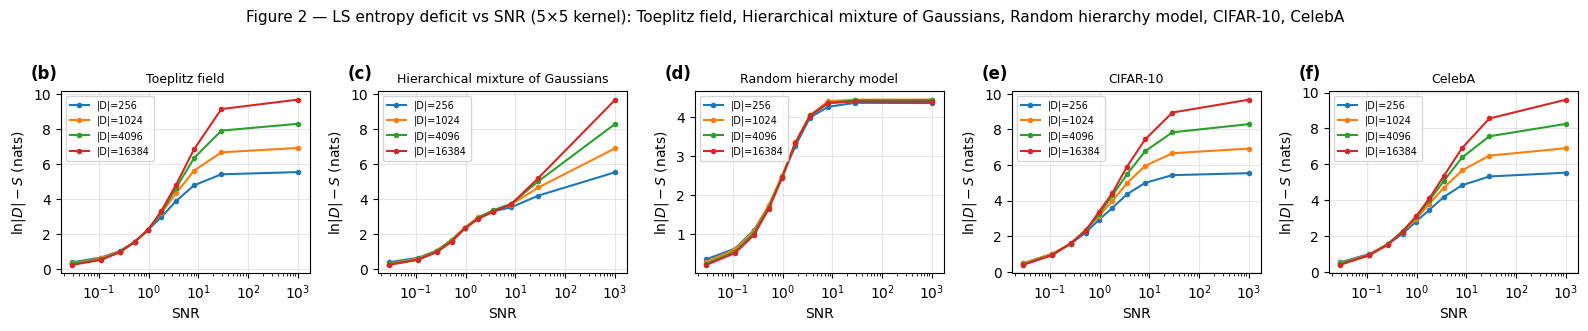

In [5]:
save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

sq = 3.2
fig, axes = plt.subplots(1, 5, figsize=(5 * sq, sq), sharey=False)
dataset_names = [
    "Toeplitz field",
    "Hierarchical mixture of Gaussians",
    "Random hierarchy model",
    "CIFAR-10",
    "CelebA",
]
fig.suptitle(
    "Figure 2 — LS entropy deficit vs SNR (5×5 kernel): "
    + ", ".join(dataset_names),
    fontsize=11,
    y=1.02,
)

for ax, (letter, info), ds_name in zip(axes, fig2_row, dataset_names):
    ax.text(
        -0.12,
        1.05,
        f"({letter})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="left",
    )
    if info is None:
        ax.set_axis_off()
        ax.text(
            0.5,
            0.5,
            "Random hierarchy\n(not implemented)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=10,
        )
        ax.set_title(f"{ds_name}", fontsize=9)
        continue
    snr = info["snr"]
    for n_train in info["n_train_list"]:
        ax.plot(snr, info["deficit_by_n"][n_train], "o-", label=f"|D|={n_train}", markersize=3)
    ax.set_xscale("log")
    ax.set_xlabel("SNR")
    ax.set_ylabel(r"$\ln|D|-S$ (nats)")
    ax.set_title(f"{ds_name}", fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=7)

plt.tight_layout()
for ext in ("png", "svg"):
    out = save_dir / f"figure2_entropy_deficit_row_bf.{ext}"
    fig.savefig(out, format=ext, bbox_inches="tight", dpi=200)
    print("Saved", out)
plt.show()